# PHLOP: Vision-Language Model Comparison

Publication-ready comparison of three vision-language models on the PHLOP static test set:

- **SmolVLM**
- **Qwen2-VL**
- **InternVL3**

Each model is evaluated under **five conditions** along the fine-tuning data ablation:

| Condition | Meaning |
|-----------|---------|
| `zero_shot` | Base (non-fine-tuned) model |
| `easy` | Fine-tuned on the *easy* split |
| `easy_medium` | Fine-tuned on the *easy + medium* split |
| `hard` | Fine-tuned on the *hard* split |
| `full` | Fine-tuned on the *full* training set |

and under **two prompting/evaluation settings**: `no_physics` (no physics hint in the prompt) and `with_physics` (physics hint included).

The notebook produces headline tables, ablation curves, per-question-type heatmaps, macro/weighted metrics, a question-category rollup, and exports publication artifacts (CSV, LaTeX, 300-DPI figures).

**Data source:** `results/phlop_data_backup/{model}_finetuned_metrics_static.json`. The `base` entry inside each file provides the zero-shot baseline.

In [ ]:
!pip install pandas numpy matplotlib

In [4]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ----------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------
RESULTS_DIR = Path("results/phlop_data_backup")
if not RESULTS_DIR.exists():
    # Allow running from the repo root as well.
    RESULTS_DIR = Path("notebooks/results/phlop_data_backup")
assert RESULTS_DIR.exists(), f"Could not locate results directory (looked at {RESULTS_DIR})"

# Write artifacts to notebooks/comparison_output (next to this notebook),
# regardless of whether the notebook is run from notebooks/ or the repo root.
OUTPUT_DIR = RESULTS_DIR.parent.parent / "comparison_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------------------
# Experiment definition
# ----------------------------------------------------------------------------
# model_key -> (display name, metrics filename)
MODELS = {
    "smolvlm": ("SmolVLM", "smolvlm_finetuned_metrics_static.json"),
    "qwen2vl": ("Qwen2-VL", "qwen2vl_finetuned_metrics_static.json"),
    "internvl3": ("InternVL3", "internvl3_finetuned_metrics_static.json"),
}
MODEL_ORDER = list(MODELS.keys())
MODEL_DISPLAY = {k: v[0] for k, v in MODELS.items()}

# Ordered ablation conditions (zero_shot first, then increasing data difficulty/size).
CONDITIONS = ["zero_shot", "easy", "easy_medium", "hard", "full"]
CONDITION_DISPLAY = {
    "zero_shot": "Zero-shot",
    "easy": "Easy",
    "easy_medium": "Easy+Med",
    "hard": "Hard",
    "full": "Full",
}

PHYSICS_SETTINGS = ["no_physics", "with_physics"]
PHYSICS_DISPLAY = {"no_physics": "No physics hint", "with_physics": "With physics hint"}

# The top-level block name is inconsistent across models: SmolVLM/InternVL3 use
# 'with_physics' while Qwen2-VL uses 'physics'. Map each canonical setting to the
# block names that may appear in the JSON (first match wins).
PHYSICS_BLOCK_ALIASES = {
    "no_physics": ["no_physics"],
    "with_physics": ["with_physics", "physics"],
}

# Consistent colors per model across all figures.
MODEL_COLORS = {
    "smolvlm": "#4C72B0",
    "qwen2vl": "#DD8452",
    "internvl3": "#55A868",
}

# ----------------------------------------------------------------------------
# Question-type taxonomy (for category-level rollups)
# ----------------------------------------------------------------------------
QTYPE_CATEGORY = {
    # Perception / counting / detection
    "object_count": "Perception",
    "stopped_objects_count": "Perception",
    "shape_distribution": "Perception",
    "collision_presence": "Perception",
    "rolling_detection": "Perception",
    "fastest_object": "Perception",
    # Physical dynamics / quantitative reasoning
    "newtons_second_law": "Dynamics",
    "velocity_scaling": "Dynamics",
    "friction_scaling": "Dynamics",
    "friction_comparison": "Dynamics",
    "friction_coefficient_comparison": "Dynamics",
    "momentum_conservation": "Dynamics",
    "energy_analysis_taxonomy": "Dynamics",
    "mass_ratio": "Dynamics",
    "relative_velocity_magnitude": "Dynamics",
    "relative_velocity_decision": "Dynamics",
    "property_competition": "Dynamics",
    # Temporal reasoning
    "stationary_duration": "Temporal",
    "stationary_start_time": "Temporal",
    "direction_reversal": "Temporal",
    "event_sequence": "Temporal",
    "temporal_consistency": "Temporal",
    # Multi-hop / causal reasoning
    "apparent_contradiction": "Causal",
    "indirect_causation": "Causal",
    "four_hop_causation": "Causal",
}
CATEGORY_ORDER = ["Perception", "Dynamics", "Temporal", "Causal"]

# ----------------------------------------------------------------------------
# Unanswerable / fallback bucket
# ----------------------------------------------------------------------------
# The 'unknown' question type is NOT a real reasoning category: it is a set of
# rows with an empty question AND empty ground truth that entered the eval set
# as phantom slots (a stale evaluation index overran the regenerated QA files,
# so PHLOPValDataset.__getitem__ returned an empty {} for out-of-range qa_idx).
# Because the harness scores accuracy with `extract_answer(gt) in extract_answer(pred)`
# and the ground truth is empty (""  is a substring of anything), every such row
# was counted as CORRECT -- silently inflating the reported answer_accuracy.
#
# We treat these as a first-class "Unanswerable (no ground truth)" fallback
# category: excluded from the headline accuracy and reported separately.
FALLBACK_QTYPES = {"unknown"}
FALLBACK_DISPLAY = "Unanswerable (no GT)"
# Question types excluded from per-type / category / headline accuracy analysis.
EXCLUDED_QTYPES = set(FALLBACK_QTYPES)

# ----------------------------------------------------------------------------
# Plot styling (matplotlib-only "whitegrid" look; no seaborn dependency)
# ----------------------------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "pdf.fonttype": 42,  # editable text in vector output
    "ps.fonttype": 42,
    # whitegrid styling
    "axes.grid": True,
    "grid.color": "#d0d0d0",
    "grid.linewidth": 0.8,
    "axes.facecolor": "#eaeaf2",
    "axes.edgecolor": "white",
    "axes.linewidth": 1.2,
    "axes.axisbelow": True,
})

print("Results dir :", RESULTS_DIR.resolve())
print("Output dir  :", OUTPUT_DIR.resolve())

Results dir : /Users/Marichka/Studing/Uni/Project/Iran/PHLOP/notebooks/results/phlop_data_backup
Output dir  : /Users/Marichka/Studing/Uni/Project/Iran/PHLOP/notebooks/comparison_output


## 1. Load and tidy the metrics

We parse each model's `*_finetuned_metrics_static.json` into two tidy tables:

- **`df`** (long, per question type): `model, physics, condition, question_type, category, accuracy, f1, count`
- **`overall`** (one row per cell): the reported `answer_accuracy` (count-weighted over questions) plus computed `macro_accuracy` and `macro_f1` over question types.

The raw condition keys are `base` (mapped to `zero_shot`) and `<model>_<level>_<physics>`. Qwen2-VL is named inconsistently in **two** ways, both handled by the parser:

1. Its top-level block is `physics` instead of `with_physics` (resolved via `PHYSICS_BLOCK_ALIASES`).
2. Its condition keys use the suffix `_physics` instead of `_with_physics` (the parser detects the ablation-level token directly).

Without these fixes Qwen's entire with-physics column would be silently dropped.

In [5]:
def _condition_from_key(key: str) -> str | None:
    """Map a raw metrics key to one of CONDITIONS, or None if unrecognized.

    Examples:
        'base'                          -> 'zero_shot'
        'smolvlm_easy_no_physics'       -> 'easy'
        'qwen2vl_easy_medium_physics'   -> 'easy_medium'
        'internvl3_full_with_physics'   -> 'full'
    """
    if key == "base":
        return "zero_shot"
    # Order matters: check 'easy_medium' before 'easy'.
    for level in ("easy_medium", "easy", "hard", "full"):
        if f"_{level}_" in f"_{key}_":
            return level
    return None


def load_model_metrics(model_key: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return (long_df, overall_df) for a single model."""
    display, filename = MODELS[model_key]
    path = RESULTS_DIR / filename
    with open(path) as fh:
        data = json.load(fh)

    static = data["static"]
    long_rows, overall_rows = [], []

    for physics in PHYSICS_SETTINGS:
        # Resolve the actual block name (handles Qwen's 'physics' vs others' 'with_physics').
        block = {}
        for alias in PHYSICS_BLOCK_ALIASES[physics]:
            if alias in static:
                block = static[alias]
                break
        for raw_key, payload in block.items():
            condition = _condition_from_key(raw_key)
            if condition is None:
                continue
            test = payload.get("test", {})
            answer_acc = test.get("answer_accuracy")
            pqt = test.get("per_question_type", {})

            accs, f1s, weights = [], [], []
            unanswerable_count = 0
            for qtype, vals in pqt.items():
                acc = vals.get("accuracy")
                f1 = vals.get("f1")
                cnt = vals.get("count", 0)
                # Filter the unanswerable bucket at the SOURCE: it is counted (for the
                # fallback report) but never added to the long table, so every
                # downstream table/figure is clean without needing its own filter.
                if qtype in EXCLUDED_QTYPES:
                    unanswerable_count += int(cnt)
                    continue
                long_rows.append({
                    "model": model_key,
                    "model_display": display,
                    "physics": physics,
                    "condition": condition,
                    "question_type": qtype,
                    "category": QTYPE_CATEGORY.get(qtype, "Other"),
                    "accuracy": acc,
                    "f1": f1,
                    "count": cnt,
                })
                accs.append(acc)
                f1s.append(f1)
                weights.append(cnt)

            n_answerable = int(sum(weights))
            n_total = n_answerable + unanswerable_count
            # Corrected headline accuracy: count-weighted over *answerable* question
            # types only (excludes the empty-GT 'unanswerable' bucket).
            weighted_acc = (
                float(np.average(accs, weights=weights))
                if accs and sum(weights) > 0 else np.nan
            )
            overall_rows.append({
                "model": model_key,
                "model_display": display,
                "physics": physics,
                "condition": condition,
                # Primary (corrected) metric used everywhere downstream.
                "answer_accuracy": weighted_acc,
                # Raw value reported by the harness (inflated by the empty-GT bucket).
                "answer_accuracy_raw": answer_acc,
                "macro_accuracy": float(np.mean(accs)) if accs else np.nan,
                "macro_f1": float(np.mean(f1s)) if f1s else np.nan,
                "weighted_accuracy": weighted_acc,
                "n_questions": n_answerable,
                "n_unanswerable": unanswerable_count,
                "unanswerable_share": (unanswerable_count / n_total) if n_total else np.nan,
            })

    return pd.DataFrame(long_rows), pd.DataFrame(overall_rows)


# Load all models and concatenate.
_long_parts, _overall_parts = [], []
for mk in MODEL_ORDER:
    ldf, odf = load_model_metrics(mk)
    _long_parts.append(ldf)
    _overall_parts.append(odf)

df = pd.concat(_long_parts, ignore_index=True)
overall = pd.concat(_overall_parts, ignore_index=True)

# Make model / condition / physics ordered categoricals for clean sorting & plotting.
df["model"] = pd.Categorical(df["model"], categories=MODEL_ORDER, ordered=True)
df["condition"] = pd.Categorical(df["condition"], categories=CONDITIONS, ordered=True)
df["physics"] = pd.Categorical(df["physics"], categories=PHYSICS_SETTINGS, ordered=True)
overall["model"] = pd.Categorical(overall["model"], categories=MODEL_ORDER, ordered=True)
overall["condition"] = pd.Categorical(overall["condition"], categories=CONDITIONS, ordered=True)
overall["physics"] = pd.Categorical(overall["physics"], categories=PHYSICS_SETTINGS, ordered=True)

overall = overall.sort_values(["physics", "model", "condition"]).reset_index(drop=True)

print(f"Loaded {len(df):,} per-question-type rows and {len(overall)} overall cells.")
print("Models     :", overall['model'].cat.categories.tolist())
print("Conditions :", overall['condition'].cat.categories.tolist())
print("Physics    :", overall['physics'].cat.categories.tolist())
overall.head(100)

Loaded 750 per-question-type rows and 30 overall cells.
Models     : ['smolvlm', 'qwen2vl', 'internvl3']
Conditions : ['zero_shot', 'easy', 'easy_medium', 'hard', 'full']
Physics    : ['no_physics', 'with_physics']


,model,model_display,physics,condition,answer_accuracy,answer_accuracy_raw,macro_accuracy,macro_f1,weighted_accuracy,n_questions,n_unanswerable,unanswerable_share
0,smolvlm,SmolVLM,no_physics,zero_shot,0.245902,0.328943,0.212993,0.041768,0.245902,22635,2801,0.11012
1,smolvlm,SmolVLM,no_physics,easy,0.614314,0.656786,0.585004,0.108139,0.614314,22635,2801,0.11012
2,smolvlm,SmolVLM,no_physics,easy_medium,0.693484,0.727237,0.677376,0.109136,0.693484,22635,2801,0.11012
3,smolvlm,SmolVLM,no_physics,hard,0.556086,0.604969,0.522391,0.098859,0.556086,22635,2801,0.11012
4,smolvlm,SmolVLM,no_physics,full,0.824254,0.843607,0.835390,0.126510,0.824254,22635,2801,0.11012
5,qwen2vl,Qwen2-VL,no_physics,zero_shot,0.130683,0.226411,0.101472,0.133188,0.130683,22635,2801,0.11012
6,qwen2vl,Qwen2-VL,no_physics,easy,0.100861,0.199874,0.089280,0.133681,0.100861,22635,2801,0.11012
7,qwen2vl,Qwen2-VL,no_physics,easy_medium,0.393285,0.460096,0.334299,0.478944,0.393285,22635,2801,0.11012
8,qwen2vl,Qwen2-VL,no_physics,hard,0.295383,0.372975,0.247003,0.452737,0.295383,22635,2801,0.11012
9,qwen2vl,Qwen2-VL,no_physics,full,0.456505,0.516355,0.425000,0.587564,0.456505,22635,2801,0.11012


## 2. Headline summary tables

Overall answer accuracy for every model x condition, shown separately for each physics setting. These pivot tables are the basis of the main results table in the paper.

**Corrected metric.** The headline `answer_accuracy` here is the count-weighted accuracy over **answerable** question types only. The raw value originally reported by the eval harness included an `unanswerable` bucket (empty-question / empty-ground-truth rows) that was always scored as correct, inflating accuracy by roughly 1-10 percentage points. We keep the raw number as `answer_accuracy_raw` for transparency and quantify the bucket via `unanswerable_share`. See the "Fallback / unanswerable handling" section for details and the root cause.

In [6]:
def accuracy_pivot(physics: str, metric: str = "answer_accuracy") -> pd.DataFrame:
    """Rows = models, columns = ordered conditions, values = metric for a physics setting."""
    sub = overall[overall["physics"] == physics]
    piv = sub.pivot_table(index="model", columns="condition",
                          values=metric, observed=True)
    piv = piv.reindex(index=MODEL_ORDER, columns=CONDITIONS)
    piv.index = [MODEL_DISPLAY[m] for m in piv.index]
    piv.columns = [CONDITION_DISPLAY[c] for c in piv.columns]
    return piv


summary_tables = {p: accuracy_pivot(p) for p in PHYSICS_SETTINGS}

for physics, piv in summary_tables.items():
    print(f"\n=== Overall answer accuracy (corrected) | {PHYSICS_DISPLAY[physics]} ===")
    display((piv * 100).round(2).style.format("{:.2f}")
            .background_gradient(cmap="Greens", axis=None)
            .set_caption(f"Answer accuracy (%), corrected (excludes unanswerable) "
                         f"- {PHYSICS_DISPLAY[physics]}"))

# A single tidy "long" headline table that includes both physics settings.
# All accuracy here is the CORRECTED metric: count-weighted over answerable
# question types only (the unanswerable bucket is excluded). The inflated
# whole-dataset value is intentionally NOT shown here to avoid confusion -- it
# lives in `overall_metrics.csv` (`answer_accuracy_raw`) and in the
# "Fallback / unanswerable handling" section, where the inflation is quantified.
headline = (overall
            .assign(model=lambda d: d["model"].map(MODEL_DISPLAY),
                    condition=lambda d: d["condition"].map(CONDITION_DISPLAY),
                    physics=lambda d: d["physics"].map(PHYSICS_DISPLAY))
            .loc[:, ["model", "physics", "condition",
                     "answer_accuracy", "macro_accuracy", "macro_f1", "n_questions"]]
            .round(4))
headline


=== Overall answer accuracy (corrected) | No physics hint ===


,Zero-shot,Easy,Easy+Med,Hard,Full
SmolVLM,24.59,61.43,69.35,55.61,82.43
Qwen2-VL,13.07,10.09,39.33,29.54,45.65
InternVL3,14.60,61.30,84.27,82.45,82.28



=== Overall answer accuracy (corrected) | With physics hint ===


,Zero-shot,Easy,Easy+Med,Hard,Full
SmolVLM,24.63,66.70,77.51,54.01,86.88
Qwen2-VL,7.61,38.00,64.23,44.56,59.59
InternVL3,13.11,64.36,91.04,87.06,90.06


,model,physics,condition,answer_accuracy,macro_accuracy,macro_f1,n_questions
0,SmolVLM,No physics hint,Zero-shot,0.2459,0.2130,0.0418,22635
1,SmolVLM,No physics hint,Easy,0.6143,0.5850,0.1081,22635
2,SmolVLM,No physics hint,Easy+Med,0.6935,0.6774,0.1091,22635
3,SmolVLM,No physics hint,Hard,0.5561,0.5224,0.0989,22635
4,SmolVLM,No physics hint,Full,0.8243,0.8354,0.1265,22635
5,Qwen2-VL,No physics hint,Zero-shot,0.1307,0.1015,0.1332,22635
6,Qwen2-VL,No physics hint,Easy,0.1009,0.0893,0.1337,22635
7,Qwen2-VL,No physics hint,Easy+Med,0.3933,0.3343,0.4789,22635
8,Qwen2-VL,No physics hint,Hard,0.2954,0.2470,0.4527,22635
9,Qwen2-VL,No physics hint,Full,0.4565,0.4250,0.5876,22635


## 3. Overall accuracy: grouped bars and ablation curves

Two complementary views of the headline metric:

- **Grouped bars** make per-condition model rankings easy to read.
- **Ablation curves** trace each model along the data ablation (`zero_shot -> easy -> easy_medium -> hard -> full`), highlighting the marginal value of harder/more training data.

All figures are registered in `FIGURES` and saved to `comparison_outputs/` (PNG + PDF, 300 DPI) in the final section.

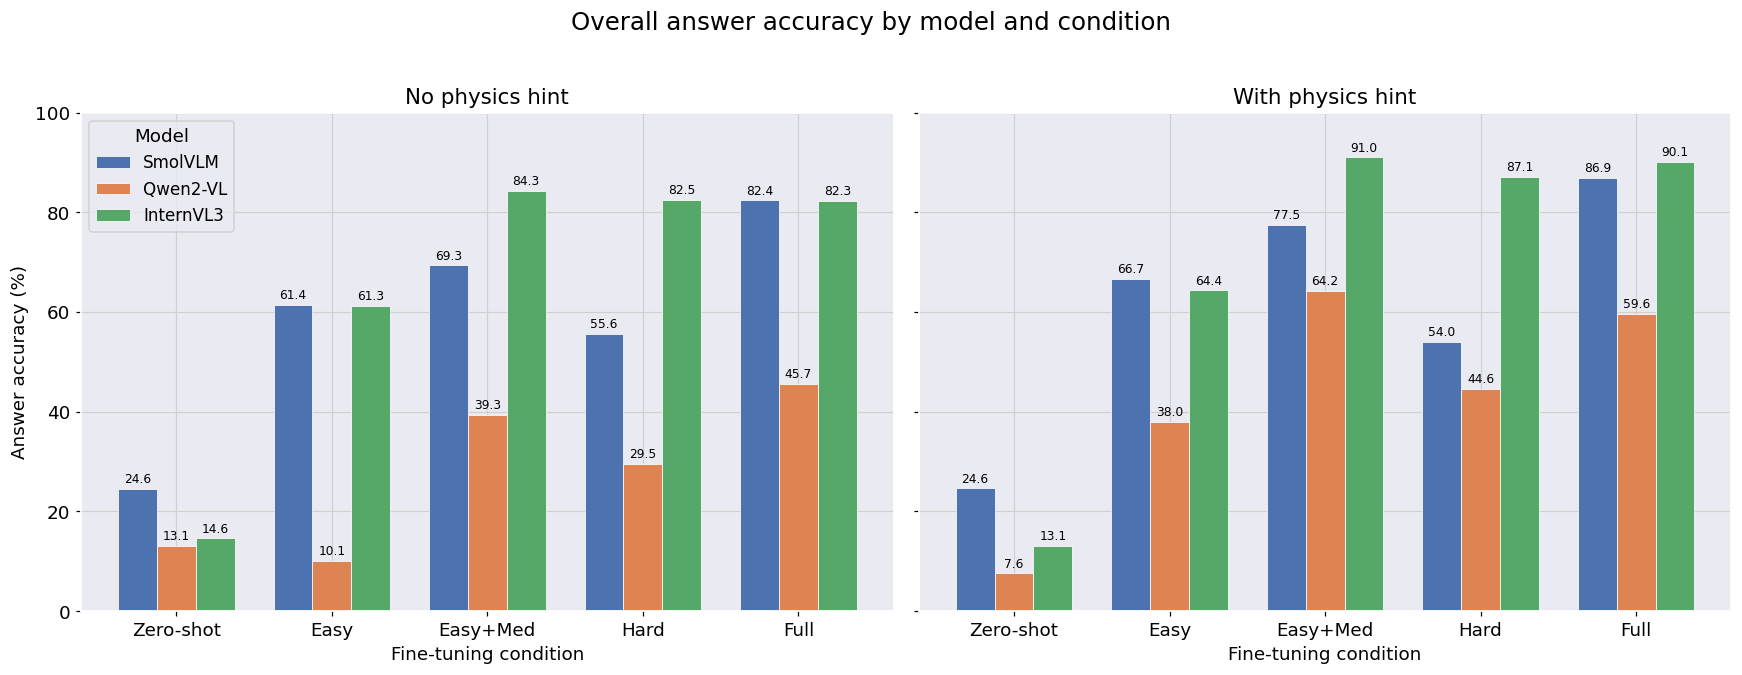

In [19]:
# Registry of figures to export at the end.
FIGURES: dict[str, plt.Figure] = {}


def register_fig(name: str, fig: plt.Figure) -> None:
    FIGURES[name] = fig


# ----------------------------------------------------------------------------
# Grouped bar chart: one panel per physics setting.
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
bar_w = 0.25
x = np.arange(len(CONDITIONS))

for ax, physics in zip(axes, PHYSICS_SETTINGS):
    piv = overall[overall["physics"] == physics].pivot_table(
        index="condition", columns="model", values="answer_accuracy", observed=True
    ).reindex(index=CONDITIONS, columns=MODEL_ORDER)

    for i, model in enumerate(MODEL_ORDER):
        vals = piv[model].values * 100
        offset = (i - 1) * bar_w
        bars = ax.bar(x + offset, vals, bar_w, label=MODEL_DISPLAY[model],
                      color=MODEL_COLORS[model], edgecolor="white", linewidth=0.5)
        ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)

    ax.set_title(PHYSICS_DISPLAY[physics])
    ax.set_xticks(x)
    ax.set_xticklabels([CONDITION_DISPLAY[c] for c in CONDITIONS], rotation=0)
    ax.set_xlabel("Fine-tuning condition")
    ax.set_ylim(0, 100)

axes[0].set_ylabel("Answer accuracy (%)")
axes[0].legend(title="Model", loc="upper left")
fig.suptitle("Overall answer accuracy by model and condition", y=1.02, fontsize=16)
fig.tight_layout()
register_fig("overall_accuracy_bars", fig)
plt.show()

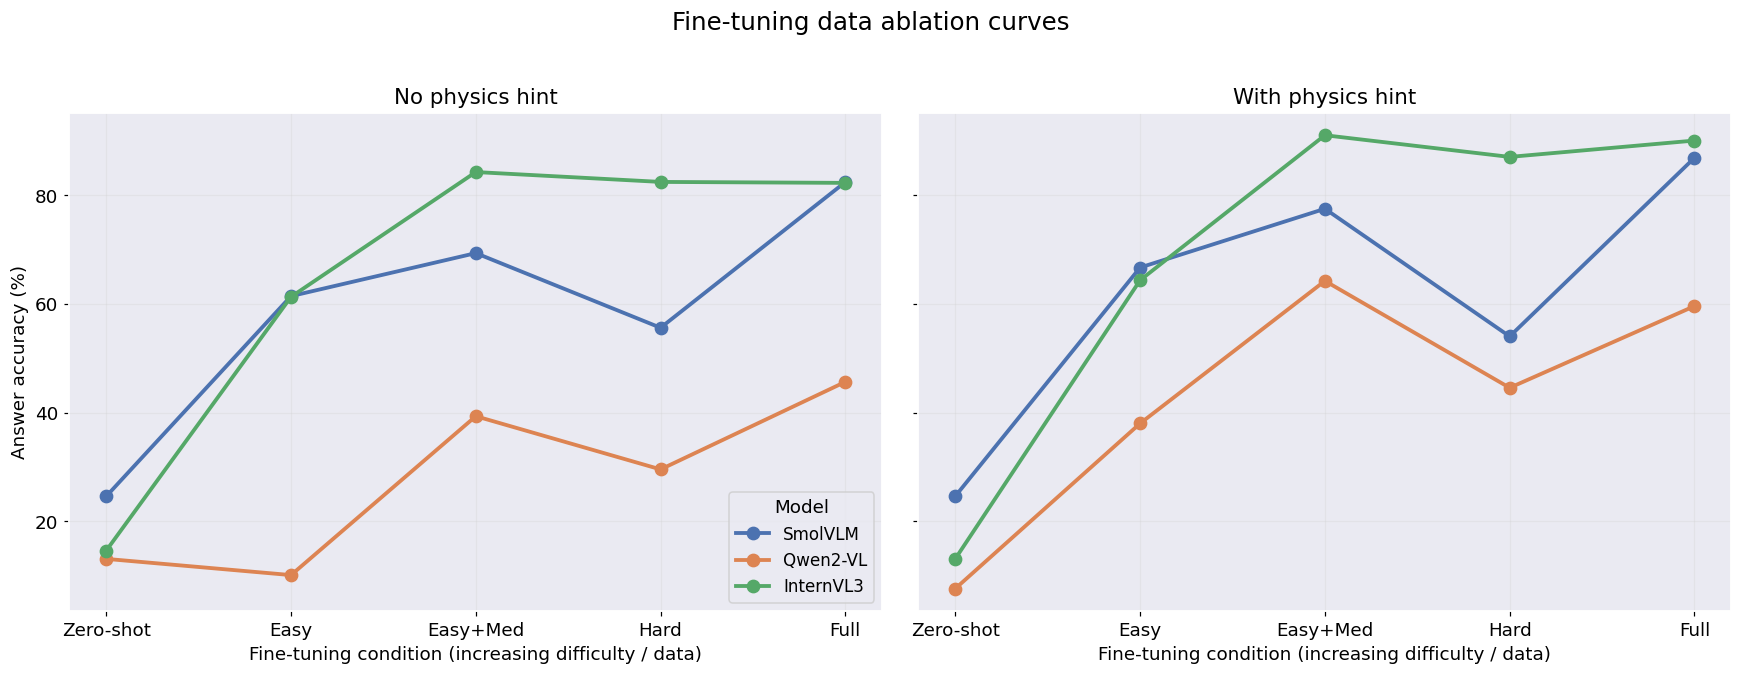

In [6]:
# ----------------------------------------------------------------------------
# Ablation curves: accuracy vs condition, one line per model, one panel per physics.
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, physics in zip(axes, PHYSICS_SETTINGS):
    piv = overall[overall["physics"] == physics].pivot_table(
        index="condition", columns="model", values="answer_accuracy", observed=True
    ).reindex(index=CONDITIONS, columns=MODEL_ORDER)

    for model in MODEL_ORDER:
        ax.plot(range(len(CONDITIONS)), piv[model].values * 100,
                marker="o", markersize=8, linewidth=2.5,
                label=MODEL_DISPLAY[model], color=MODEL_COLORS[model])

    ax.set_title(PHYSICS_DISPLAY[physics])
    ax.set_xticks(range(len(CONDITIONS)))
    ax.set_xticklabels([CONDITION_DISPLAY[c] for c in CONDITIONS])
    ax.set_xlabel("Fine-tuning condition (increasing difficulty / data)")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Answer accuracy (%)")
axes[0].legend(title="Model", loc="lower right")
fig.suptitle("Fine-tuning data ablation curves", y=1.02, fontsize=16)
fig.tight_layout()
register_fig("ablation_curves", fig)
plt.show()

## 4. Gains from fine-tuning (vs. zero-shot)

For each model and physics setting we measure how much each fine-tuned condition improves over that model's own zero-shot baseline:

- **Absolute gain** = `acc(condition) - acc(zero_shot)` (percentage points)
- **Relative gain** = `acc(condition) / acc(zero_shot) - 1` (%)

This isolates the effect of fine-tuning data from the differing starting points of the three base models.

,model,physics,condition,zero_shot_acc,answer_accuracy,abs_gain_pp,rel_gain_pct
1,SmolVLM,No physics hint,Easy,0.2459,0.6143,36.84,149.8
2,SmolVLM,No physics hint,Easy+Med,0.2459,0.6935,44.76,182.0
3,SmolVLM,No physics hint,Hard,0.2459,0.5561,31.02,126.1
4,SmolVLM,No physics hint,Full,0.2459,0.8243,57.84,235.2
6,Qwen2-VL,No physics hint,Easy,0.1307,0.1009,-2.98,-22.8
7,Qwen2-VL,No physics hint,Easy+Med,0.1307,0.3933,26.26,200.9
8,Qwen2-VL,No physics hint,Hard,0.1307,0.2954,16.47,126.0
9,Qwen2-VL,No physics hint,Full,0.1307,0.4565,32.58,249.3
11,InternVL3,No physics hint,Easy,0.1460,0.6130,46.70,319.9
12,InternVL3,No physics hint,Easy+Med,0.1460,0.8427,69.67,477.3


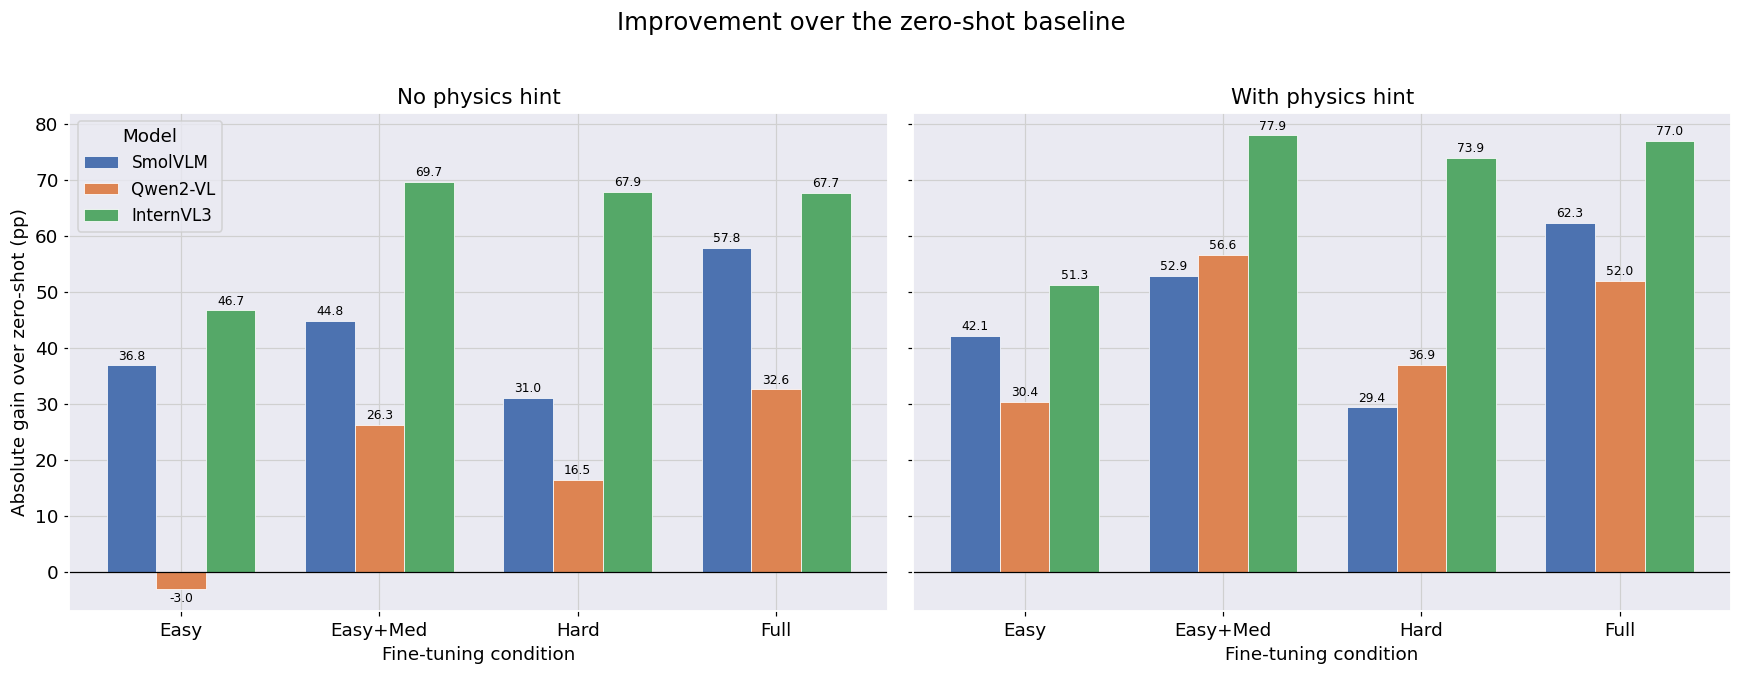

In [7]:
# Build per-(model, physics) zero-shot baseline and join back.
baseline = (overall[overall["condition"] == "zero_shot"]
            .set_index(["model", "physics"])["answer_accuracy"]
            .rename("zero_shot_acc"))

imp = overall.join(baseline, on=["model", "physics"]).copy()
imp = imp[imp["condition"] != "zero_shot"].copy()
imp["abs_gain_pp"] = (imp["answer_accuracy"] - imp["zero_shot_acc"]) * 100
imp["rel_gain_pct"] = (imp["answer_accuracy"] / imp["zero_shot_acc"] - 1) * 100

improvement_table = (imp
    .assign(model=lambda d: d["model"].map(MODEL_DISPLAY),
            condition=lambda d: d["condition"].map(CONDITION_DISPLAY),
            physics=lambda d: d["physics"].map(PHYSICS_DISPLAY))
    .loc[:, ["model", "physics", "condition", "zero_shot_acc",
             "answer_accuracy", "abs_gain_pp", "rel_gain_pct"]]
    .round({"zero_shot_acc": 4, "answer_accuracy": 4,
            "abs_gain_pp": 2, "rel_gain_pct": 1}))
display(improvement_table)

# Chart: absolute gain (percentage points) over zero-shot.
ft_conditions = [c for c in CONDITIONS if c != "zero_shot"]
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
bar_w = 0.25
x = np.arange(len(ft_conditions))

for ax, physics in zip(axes, PHYSICS_SETTINGS):
    piv = imp[imp["physics"] == physics].pivot_table(
        index="condition", columns="model", values="abs_gain_pp", observed=True
    ).reindex(index=ft_conditions, columns=MODEL_ORDER)

    for i, model in enumerate(MODEL_ORDER):
        vals = piv[model].values
        bars = ax.bar(x + (i - 1) * bar_w, vals, bar_w,
                      label=MODEL_DISPLAY[model], color=MODEL_COLORS[model],
                      edgecolor="white", linewidth=0.5)
        ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(PHYSICS_DISPLAY[physics])
    ax.set_xticks(x)
    ax.set_xticklabels([CONDITION_DISPLAY[c] for c in ft_conditions])
    ax.set_xlabel("Fine-tuning condition")

axes[0].set_ylabel("Absolute gain over zero-shot (pp)")
axes[0].legend(title="Model", loc="best")
fig.suptitle("Improvement over the zero-shot baseline", y=1.02, fontsize=16)
fig.tight_layout()
register_fig("improvement_over_zeroshot", fig)
plt.show()

## 5. Effect of the physics hint

Does adding a physics hint to the prompt help? For each model x condition we compute

`delta = acc(with_physics) - acc(no_physics)` (percentage points),

so positive values mean the physics hint improved accuracy. A diverging bar chart makes the sign and magnitude easy to read.

physics,model,condition,no_physics,with_physics,delta_pp
0,SmolVLM,Zero-shot,0.2459,0.2463,0.04
1,SmolVLM,Easy,0.6143,0.6670,5.27
2,SmolVLM,Easy+Med,0.6935,0.7751,8.16
3,SmolVLM,Hard,0.5561,0.5401,-1.59
4,SmolVLM,Full,0.8243,0.8688,4.46
5,Qwen2-VL,Zero-shot,0.1307,0.0761,-5.46
6,Qwen2-VL,Easy,0.1009,0.3800,27.92
7,Qwen2-VL,Easy+Med,0.3933,0.6423,24.90
8,Qwen2-VL,Hard,0.2954,0.4456,15.02
9,Qwen2-VL,Full,0.4565,0.5959,13.94


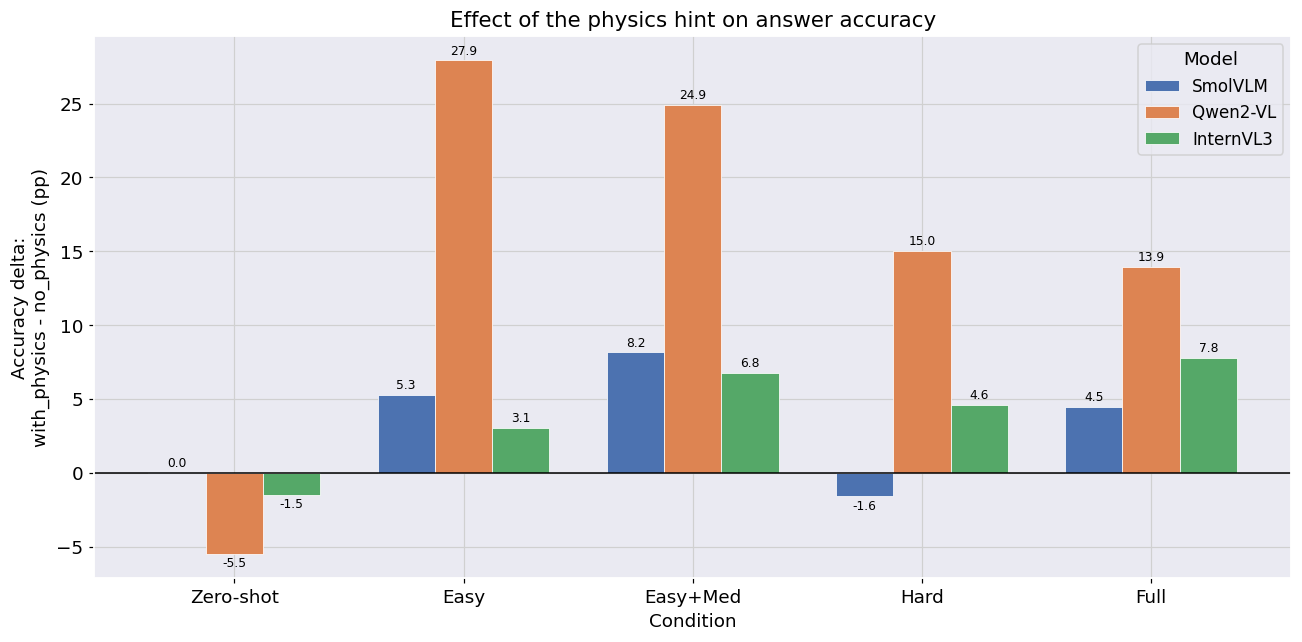

In [8]:
# Wide table: accuracy per physics + delta.
phys_wide = overall.pivot_table(
    index=["model", "condition"], columns="physics",
    values="answer_accuracy", observed=True
).reindex(columns=PHYSICS_SETTINGS)
phys_wide["delta_pp"] = (phys_wide["with_physics"] - phys_wide["no_physics"]) * 100

physics_delta_table = (phys_wide.reset_index()
    .assign(model=lambda d: d["model"].map(MODEL_DISPLAY),
            condition=lambda d: d["condition"].map(CONDITION_DISPLAY))
    .round({"no_physics": 4, "with_physics": 4, "delta_pp": 2}))
display(physics_delta_table)

# Diverging bar chart of the delta, grouped by condition.
piv = phys_wide["delta_pp"].unstack("model").reindex(
    index=CONDITIONS, columns=MODEL_ORDER)

fig, ax = plt.subplots(figsize=(12, 6))
bar_w = 0.25
x = np.arange(len(CONDITIONS))
for i, model in enumerate(MODEL_ORDER):
    vals = piv[model].values
    bars = ax.bar(x + (i - 1) * bar_w, vals, bar_w,
                  label=MODEL_DISPLAY[model], color=MODEL_COLORS[model],
                  edgecolor="white", linewidth=0.5)
    ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)

ax.axhline(0, color="black", linewidth=1.0)
ax.set_xticks(x)
ax.set_xticklabels([CONDITION_DISPLAY[c] for c in CONDITIONS])
ax.set_xlabel("Condition")
ax.set_ylabel("Accuracy delta:\nwith_physics - no_physics (pp)")
ax.set_title("Effect of the physics hint on answer accuracy")
ax.legend(title="Model", loc="best")
fig.tight_layout()
register_fig("physics_hint_delta", fig)
plt.show()

## 6. Per-question-type heatmaps

Accuracy for every question type (rows, grouped by reasoning category) across conditions (columns), one heatmap per model. This exposes *where* fine-tuning helps and which capabilities remain hard. The `unknown` bucket is excluded. A grid is drawn for each physics setting.

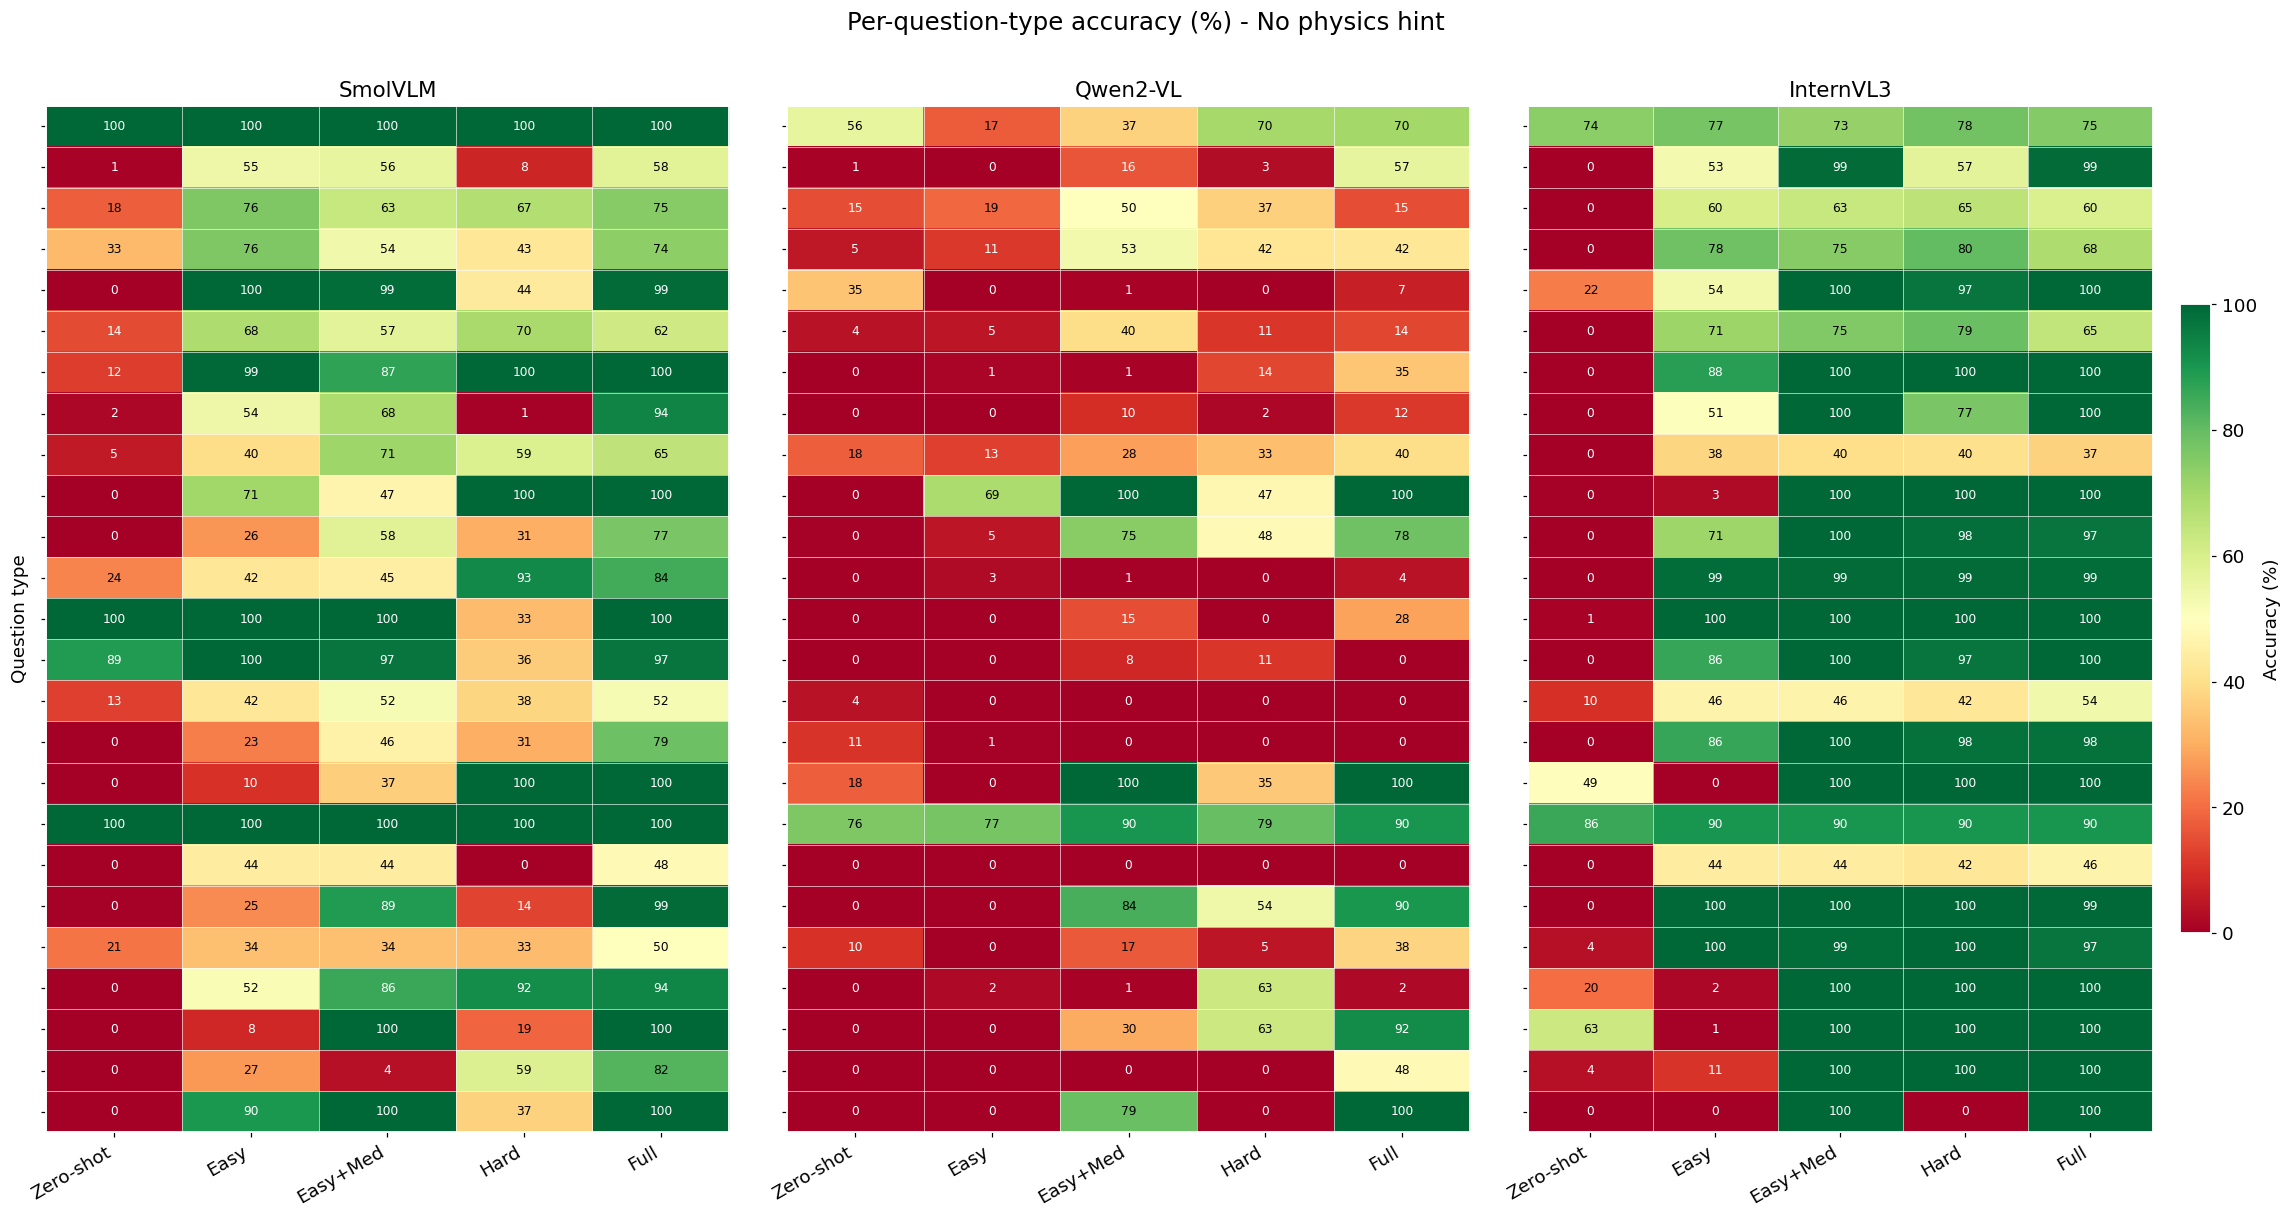

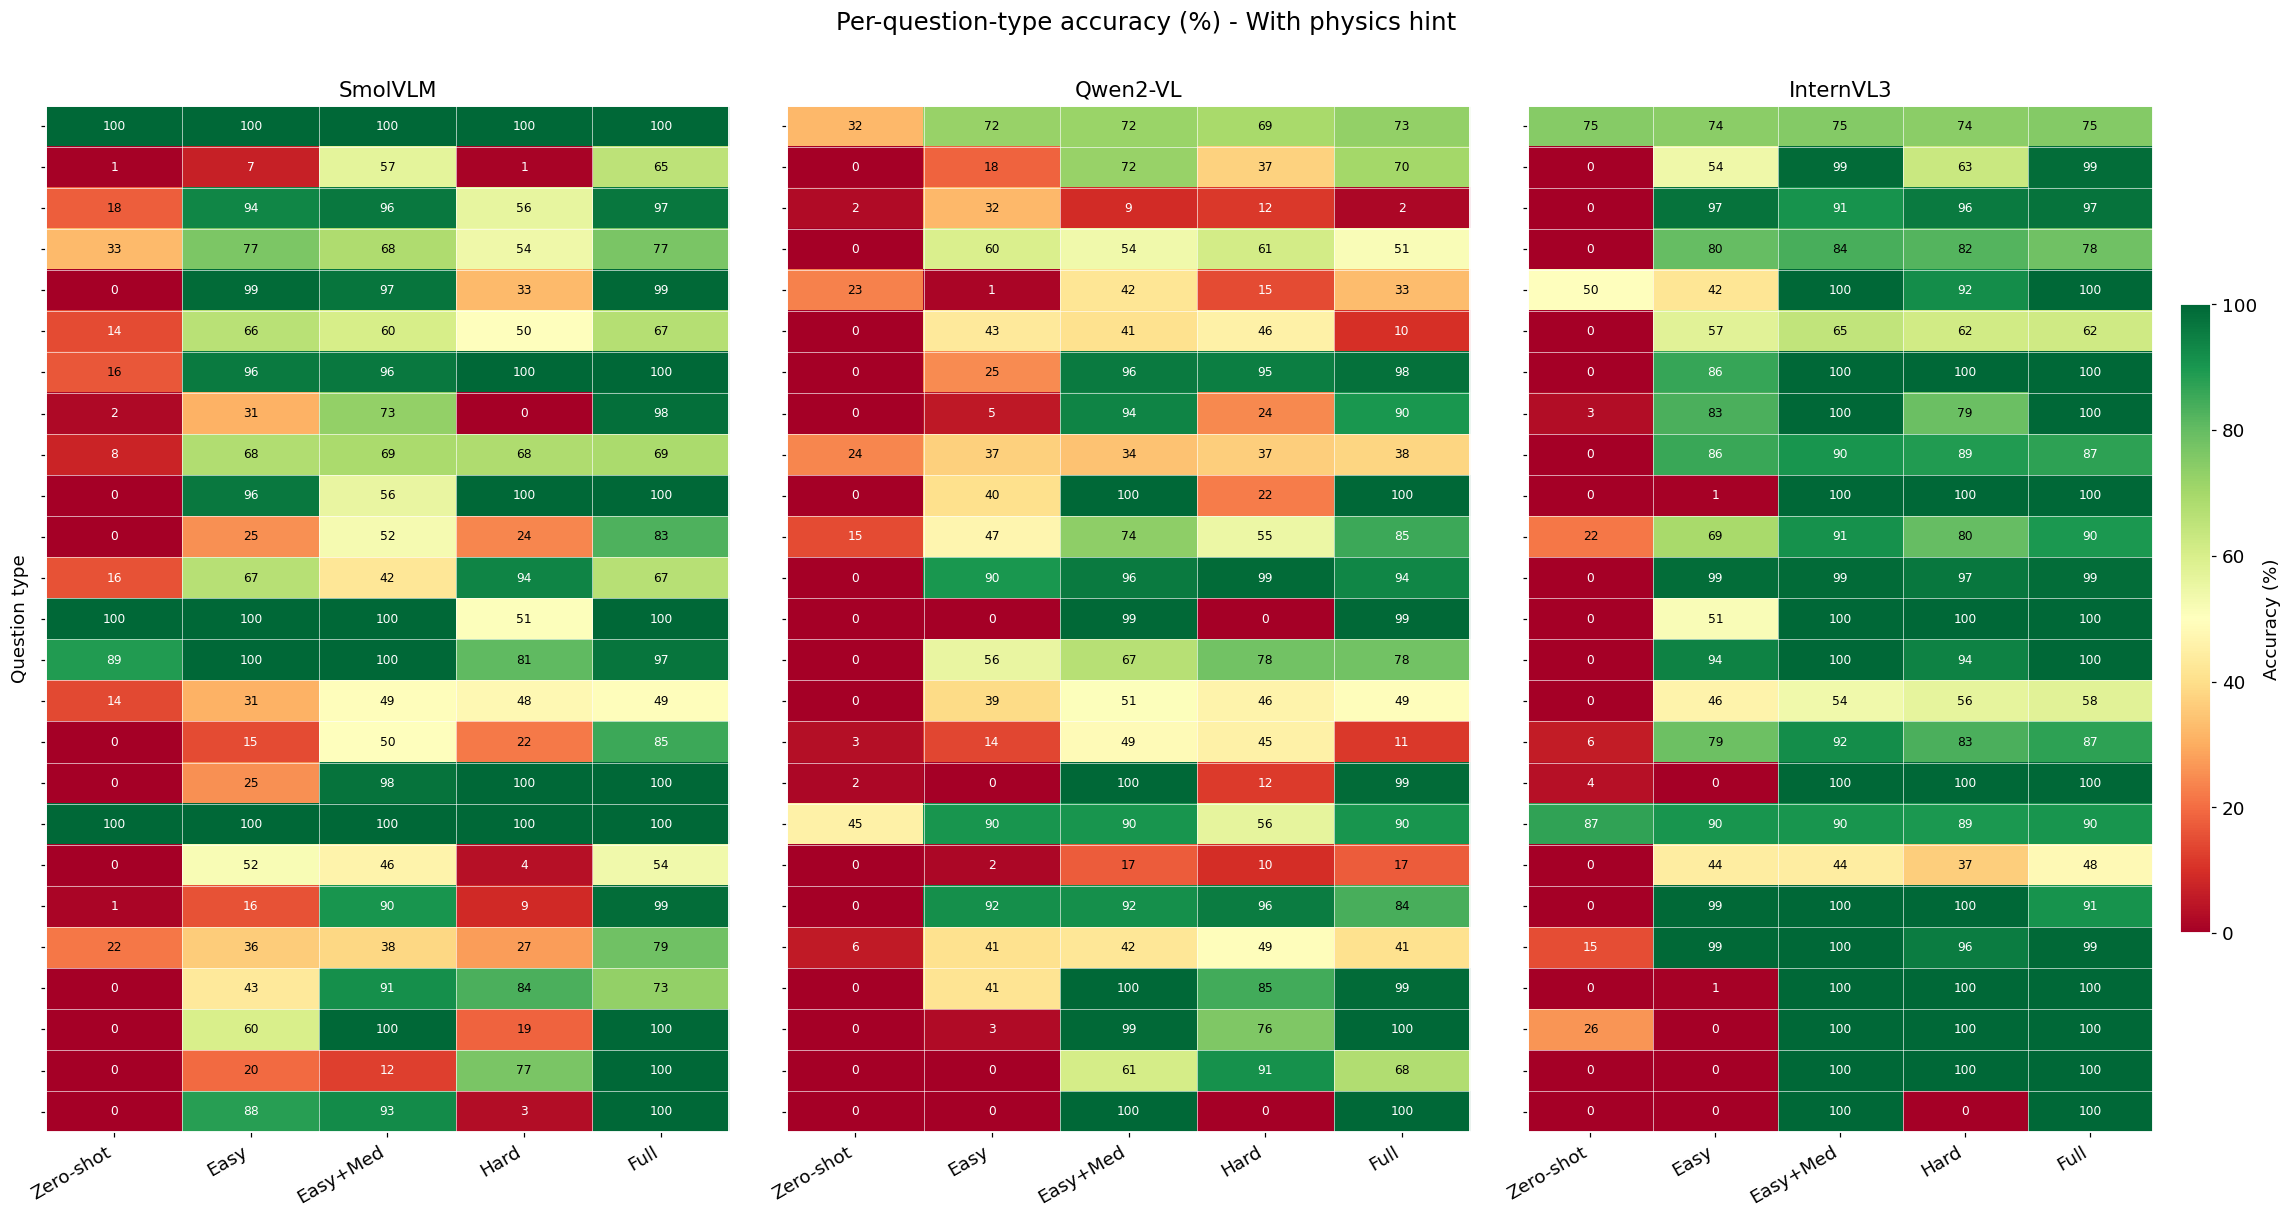

In [9]:
# Order question types by category, then alphabetically within a category.
qtypes_ordered = [
    q for cat in CATEGORY_ORDER
    for q in sorted(t for t, c in QTYPE_CATEGORY.items() if c == cat)
]


def _annotated_heatmap(ax, matrix, row_labels, col_labels, *, vmin=0, vmax=100,
                       cmap="RdYlGn", show_cbar=False, cbar_label="",
                       show_yticklabels=True):
    """Matplotlib-only annotated heatmap (replaces seaborn.heatmap)."""
    data = np.asarray(matrix, dtype=float)
    im = ax.imshow(np.ma.masked_invalid(data), aspect="auto",
                   cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(col_labels)))
    ax.set_yticks(range(len(row_labels)))
    ax.set_xticklabels(col_labels)
    ax.set_yticklabels(row_labels if show_yticklabels else [""] * len(row_labels))
    # white cell separators via a minor grid
    ax.set_xticks(np.arange(-0.5, len(col_labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.4)
    ax.grid(which="major", visible=False)
    ax.tick_params(which="minor", length=0)
    norm = im.norm
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            if np.isnan(v):
                continue
            r, g, b, _ = im.cmap(norm(v))
            lum = 0.299 * r + 0.587 * g + 0.114 * b
            ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                    fontsize=8, color="black" if lum > 0.5 else "white")
    if show_cbar:
        cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(cbar_label)
    return im


def qtype_heatmap_grid(physics: str) -> plt.Figure:
    sub = df[(df["physics"] == physics) & (~df["question_type"].isin(EXCLUDED_QTYPES))]
    fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(7 * len(MODEL_ORDER), 11),
                             sharey=True)
    for ax, model in zip(axes, MODEL_ORDER):
        piv = (sub[sub["model"] == model]
               .pivot_table(index="question_type", columns="condition",
                            values="accuracy", observed=True)
               .reindex(index=qtypes_ordered, columns=CONDITIONS))
        _annotated_heatmap(
            ax, piv.values * 100, qtypes_ordered,
            [CONDITION_DISPLAY[c] for c in CONDITIONS],
            vmin=0, vmax=100, cmap="RdYlGn",
            show_cbar=(model == MODEL_ORDER[-1]), cbar_label="Accuracy (%)",
            show_yticklabels=(model == MODEL_ORDER[0]),
        )
        ax.set_title(MODEL_DISPLAY[model])
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelrotation=30)
        for _lbl in ax.get_xticklabels():
            _lbl.set_ha("right")
        ax.set_ylabel("Question type" if model == MODEL_ORDER[0] else "")

    fig.suptitle(f"Per-question-type accuracy (%) - {PHYSICS_DISPLAY[physics]}",
                 y=1.005, fontsize=16)
    fig.tight_layout()
    return fig


for physics in PHYSICS_SETTINGS:
    fig = qtype_heatmap_grid(physics)
    register_fig(f"qtype_heatmap_{physics}", fig)
    plt.show()

## 7. Macro vs. weighted metrics

The headline `answer_accuracy` is dominated by high-frequency question types. To check robustness across the *full* capability spectrum we also report, averaged uniformly over question types:

- **Macro accuracy** = unweighted mean of per-type accuracy
- **Macro F1** = unweighted mean of per-type F1

A large gap between weighted and macro accuracy signals that gains are concentrated in a few common question types.

,model,physics,condition,weighted_acc,macro_accuracy,macro_f1
0,SmolVLM,No physics hint,Zero-shot,0.2459,0.2130,0.0418
1,SmolVLM,No physics hint,Easy,0.6143,0.5850,0.1081
2,SmolVLM,No physics hint,Easy+Med,0.6935,0.6774,0.1091
3,SmolVLM,No physics hint,Hard,0.5561,0.5224,0.0989
4,SmolVLM,No physics hint,Full,0.8243,0.8354,0.1265
5,Qwen2-VL,No physics hint,Zero-shot,0.1307,0.1015,0.1332
6,Qwen2-VL,No physics hint,Easy,0.1009,0.0893,0.1337
7,Qwen2-VL,No physics hint,Easy+Med,0.3933,0.3343,0.4789
8,Qwen2-VL,No physics hint,Hard,0.2954,0.2470,0.4527
9,Qwen2-VL,No physics hint,Full,0.4565,0.4250,0.5876


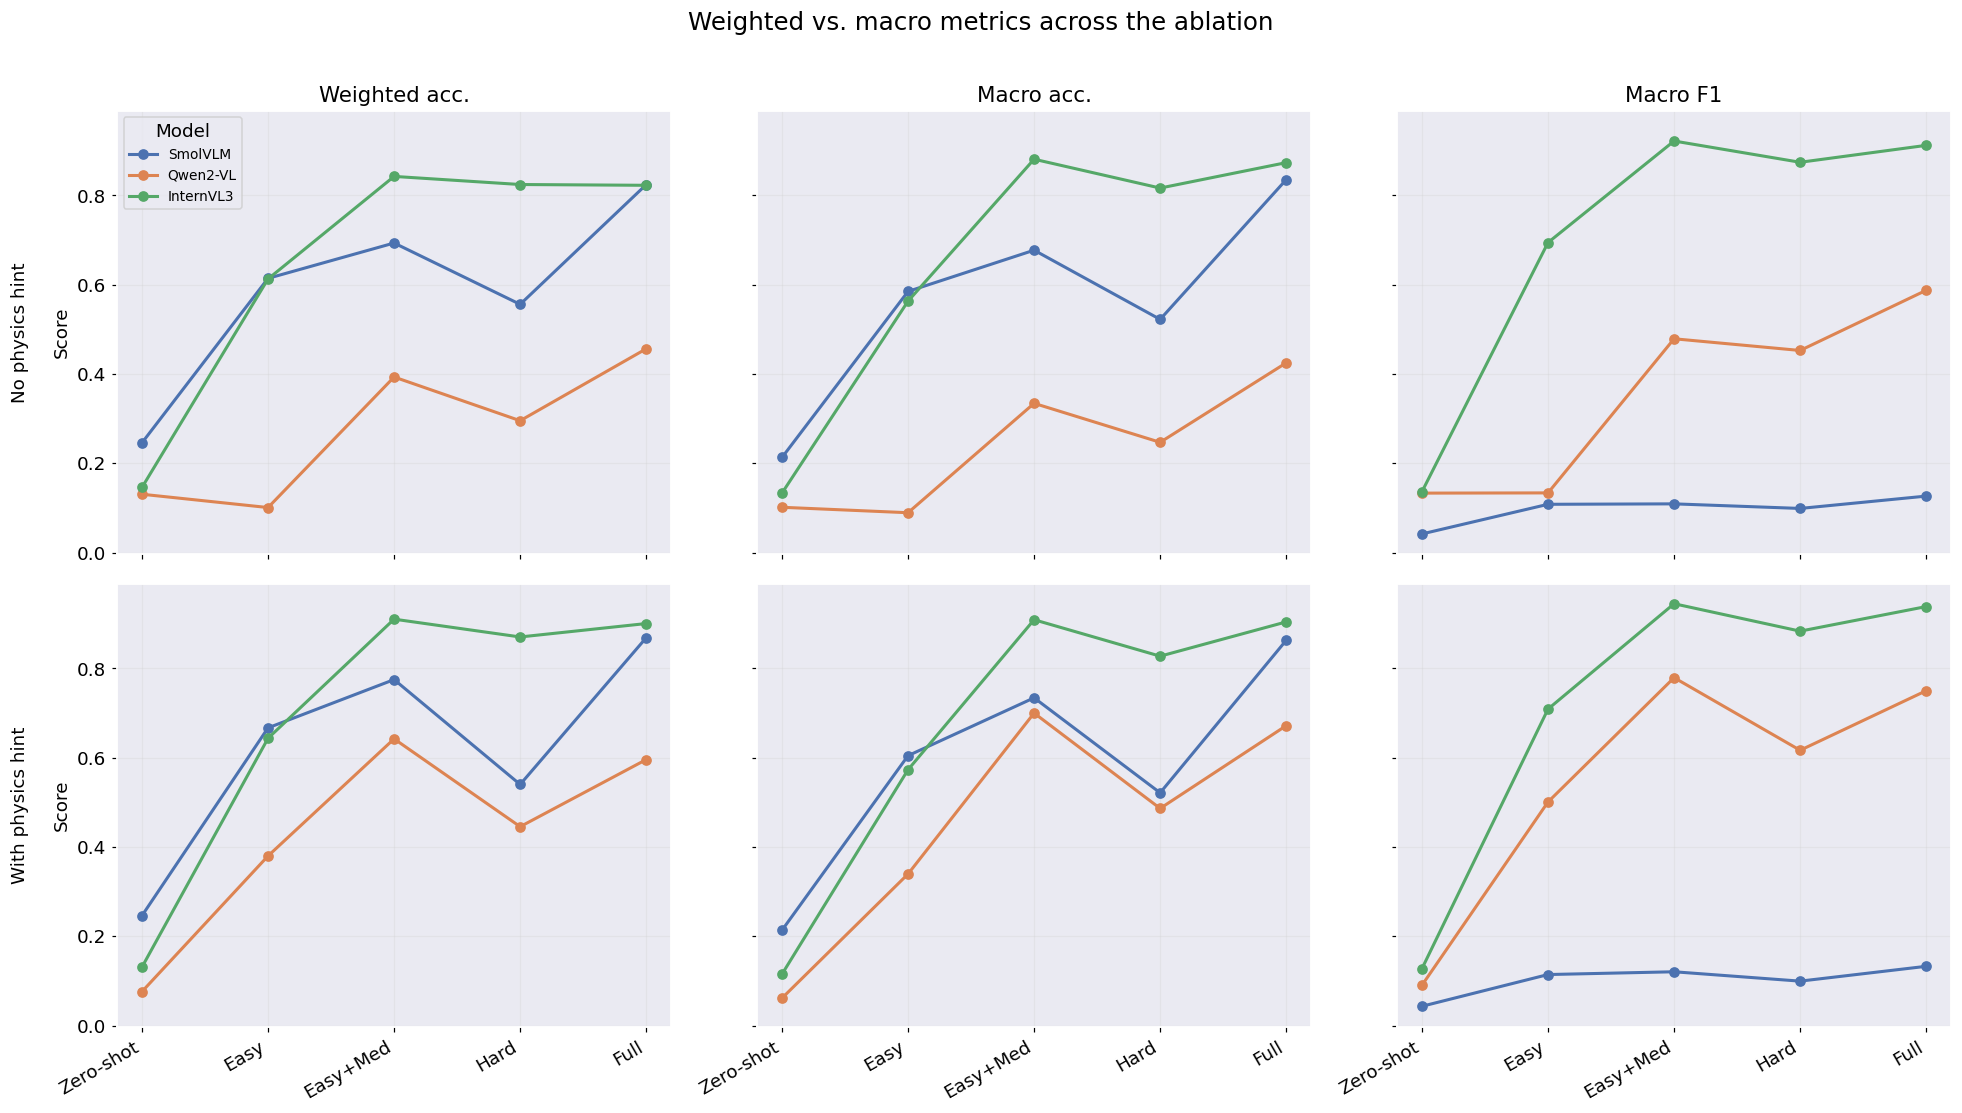

In [10]:
macro_table = (overall
    .assign(model=lambda d: d["model"].map(MODEL_DISPLAY),
            condition=lambda d: d["condition"].map(CONDITION_DISPLAY),
            physics=lambda d: d["physics"].map(PHYSICS_DISPLAY))
    .loc[:, ["model", "physics", "condition", "answer_accuracy",
             "macro_accuracy", "macro_f1"]]
    .rename(columns={"answer_accuracy": "weighted_acc"})
    .round(4))
display(macro_table)

# Compare weighted accuracy, macro accuracy and macro F1 across conditions.
metrics_to_plot = [("answer_accuracy", "Weighted acc."),
                   ("macro_accuracy", "Macro acc."),
                   ("macro_f1", "Macro F1")]
fig, axes = plt.subplots(len(PHYSICS_SETTINGS), len(metrics_to_plot),
                         figsize=(18, 10), sharex=True, sharey=True)

for r, physics in enumerate(PHYSICS_SETTINGS):
    sub = overall[overall["physics"] == physics]
    for c, (metric, label) in enumerate(metrics_to_plot):
        ax = axes[r, c]
        piv = sub.pivot_table(index="condition", columns="model",
                              values=metric, observed=True).reindex(
            index=CONDITIONS, columns=MODEL_ORDER)
        for model in MODEL_ORDER:
            ax.plot(range(len(CONDITIONS)), piv[model].values,
                    marker="o", linewidth=2, color=MODEL_COLORS[model],
                    label=MODEL_DISPLAY[model])
        ax.set_xticks(range(len(CONDITIONS)))
        ax.set_xticklabels([CONDITION_DISPLAY[c2] for c2 in CONDITIONS],
                           rotation=30, ha="right")
        ax.grid(True, alpha=0.3)
        if r == 0:
            ax.set_title(label)
        if c == 0:
            ax.set_ylabel(f"{PHYSICS_DISPLAY[physics]}\n\nScore")

axes[0, 0].legend(title="Model", fontsize=9, loc="best")
fig.suptitle("Weighted vs. macro metrics across the ablation", y=1.01, fontsize=16)
fig.tight_layout()
register_fig("macro_vs_weighted", fig)
plt.show()

## 8. Capability-category rollup

We group the 26 question types into four reasoning categories - **Perception**, **Dynamics**, **Temporal**, **Causal** - and report count-weighted accuracy per category. This gives a compact, interpretable capability profile per model and condition, well-suited to a radar/grouped-bar figure in the paper.

category                               Perception  Dynamics  Temporal  Causal
model     physics           condition                                        
SmolVLM   No physics hint   Zero-shot      0.3129    0.2247    0.1687  0.0000
                            Easy           0.7974    0.5423    0.3641  0.1384
                            Easy+Med       0.7108    0.6461    0.6542  0.9550
                            Hard           0.5941    0.6474    0.3289  0.2193
                            Full           0.7813    0.8768    0.7720  0.9917
          With physics hint Zero-shot      0.3124    0.2242    0.1745  0.0000
                            Easy           0.7723    0.6705    0.3317  0.5972
                            Easy+Med       0.8049    0.7445    0.6840  0.9516
                            Hard           0.5351    0.7011    0.2815  0.2052
                            Full           0.8469    0.8740    0.8790  1.0000
Qwen2-VL  No physics hint   Zero-shot      0.1984    0.0714    0.1025  0.0000
                            Easy           0.0996    0.1337    0.0615  0.0000
                            Easy+Med       0.3604    0.4089    0.4954  0.3128
                            Hard           0.3045    0.2214    0.3474  0.5638
                            Full           0.3400    0.4818    0.6103  0.9083
          With physics hint Zero-shot      0.0965    0.0671    0.0596  0.0000
                            Easy           0.4139    0.2803    0.6539  0.0234
                            Easy+Med       0.4680    0.8014    0.6990  0.9766
                            Hard           0.4164    0.3368    0.7089  0.7256
                            Full           0.3793    0.8010    0.6580  0.9842
InternVL3 No physics hint   Zero-shot      0.1684    0.0728    0.0938  0.5638
                            Easy           0.6728    0.5022    0.9219  0.0100
                            Easy+Med       0.7833    0.8447    0.9763  1.0000
                            Hard           0.7638    0.8244    0.9824  0.9441
                            Full           0.7480    0.8376    0.9680  1.0000
          With physics hint Zero-shot      0.2063    0.0145    0.1310  0.2369
                            Easy           0.6995    0.5583    0.9174  0.0000
                            Easy+Med       0.8376    0.9662    0.9805  1.0000
                            Hard           0.7849    0.9376    0.9613  0.9441
                            Full           0.8334    0.9582    0.9436  1.0000

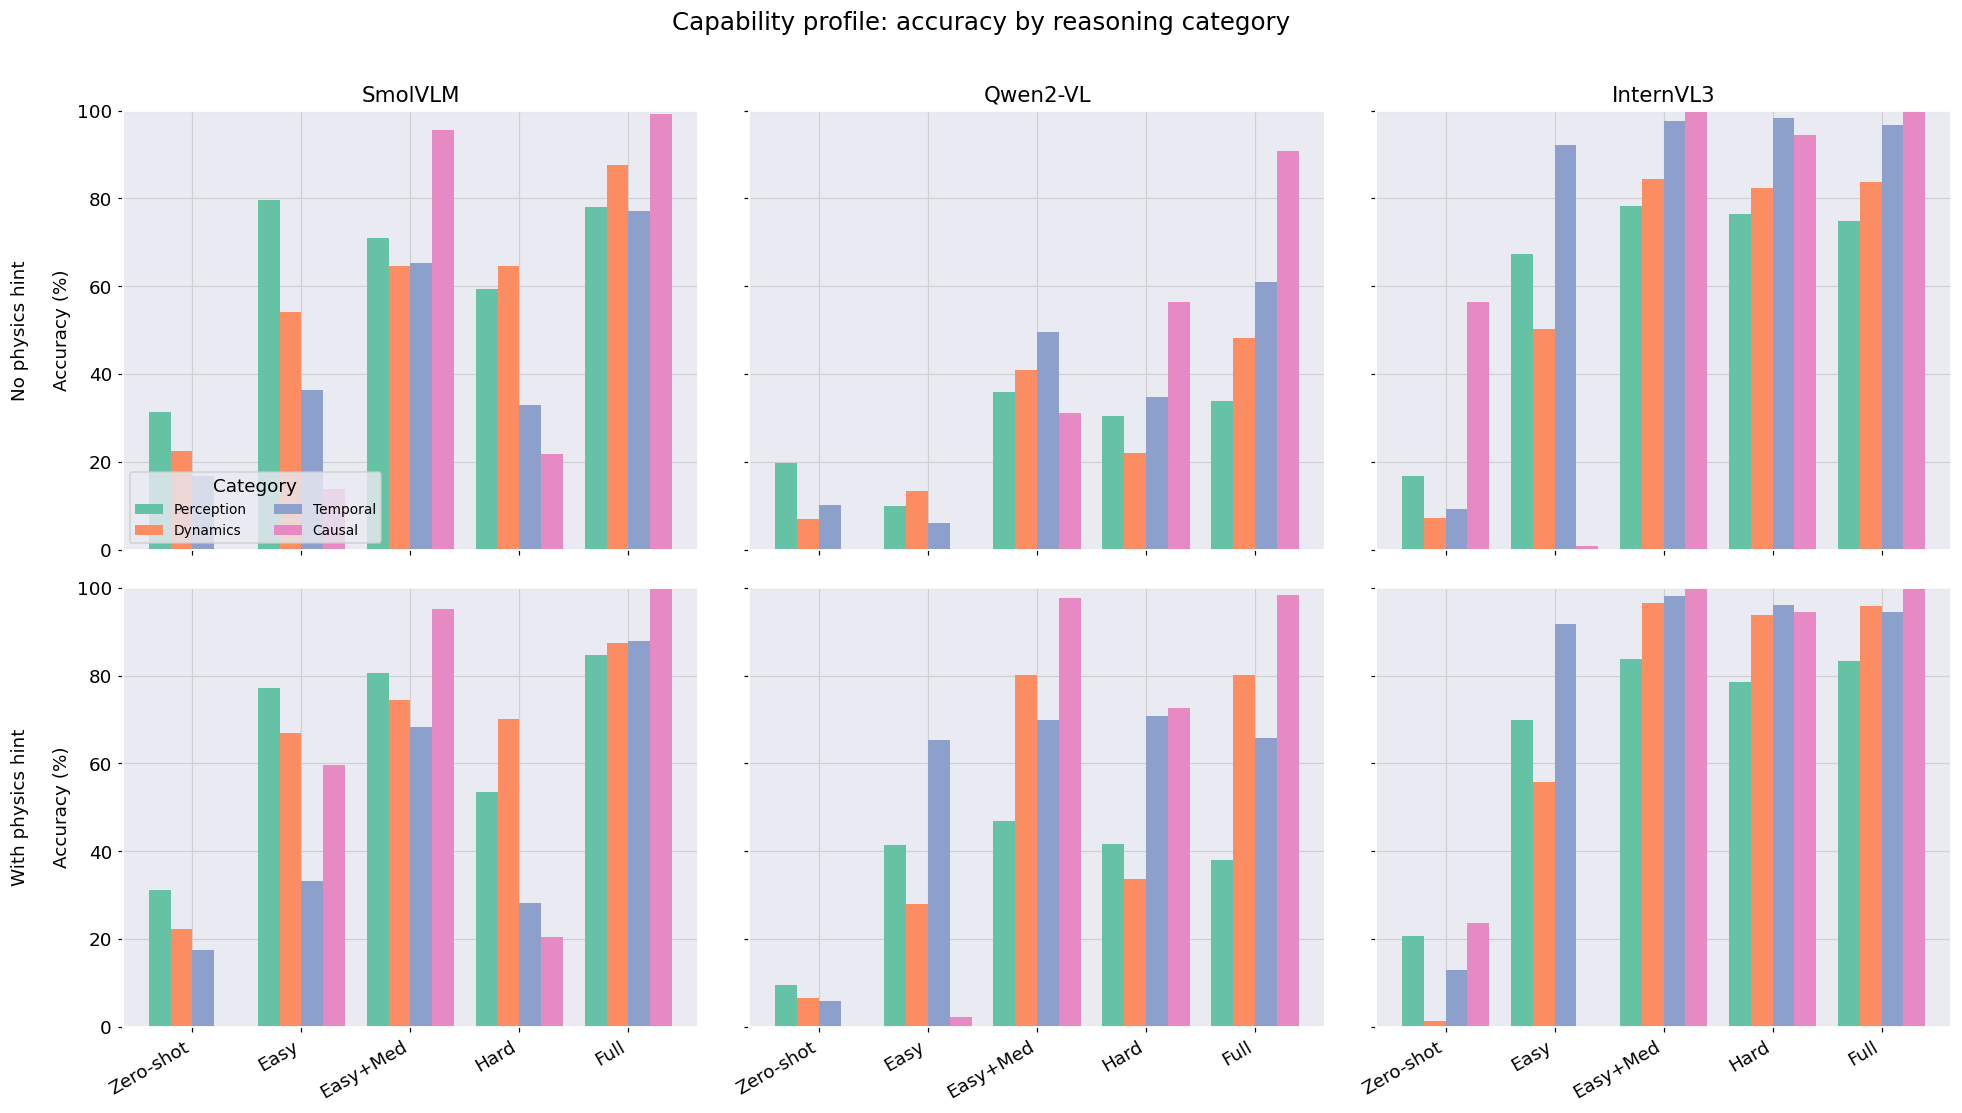

In [11]:
# Count-weighted accuracy per category, computed without DataFrame.apply so it
# is robust across pandas versions (no `include_groups` dependency).
cat_df = df[~df["question_type"].isin(EXCLUDED_QTYPES)].copy()
cat_df["_acc_x_count"] = cat_df["accuracy"] * cat_df["count"]
_grp = cat_df.groupby(["model", "physics", "condition", "category"], observed=True)
category_rollup = (_grp["_acc_x_count"].sum() / _grp["count"].sum()).rename("accuracy").reset_index()

category_table = (category_rollup
    .assign(model=lambda d: d["model"].map(MODEL_DISPLAY),
            condition=lambda d: d["condition"].map(CONDITION_DISPLAY),
            physics=lambda d: d["physics"].map(PHYSICS_DISPLAY))
    .pivot_table(index=["model", "physics", "condition"],
                 columns="category", values="accuracy", observed=True)
    .reindex(columns=CATEGORY_ORDER)
    .round(4))
display(category_table)

# Grouped bars: category accuracy per condition, faceted by model x physics.
fig, axes = plt.subplots(len(PHYSICS_SETTINGS), len(MODEL_ORDER),
                         figsize=(18, 10), sharex=True, sharey=True)
_set2 = plt.get_cmap("Set2")
cat_colors = {cat: _set2(i) for i, cat in enumerate(CATEGORY_ORDER)}
x = np.arange(len(CONDITIONS))
bar_w = 0.2

for r, physics in enumerate(PHYSICS_SETTINGS):
    for c, model in enumerate(MODEL_ORDER):
        ax = axes[r, c]
        sub = category_rollup[(category_rollup["physics"] == physics)
                              & (category_rollup["model"] == model)]
        piv = sub.pivot_table(index="condition", columns="category",
                              values="accuracy", observed=True).reindex(
            index=CONDITIONS, columns=CATEGORY_ORDER)
        for i, cat in enumerate(CATEGORY_ORDER):
            ax.bar(x + (i - 1.5) * bar_w, piv[cat].values * 100, bar_w,
                   label=cat, color=cat_colors[cat])
        ax.set_ylim(0, 100)
        ax.set_xticks(x)
        ax.set_xticklabels([CONDITION_DISPLAY[c2] for c2 in CONDITIONS],
                           rotation=30, ha="right")
        if r == 0:
            ax.set_title(MODEL_DISPLAY[model])
        if c == 0:
            ax.set_ylabel(f"{PHYSICS_DISPLAY[physics]}\n\nAccuracy (%)")

axes[0, 0].legend(title="Category", fontsize=9, ncol=2, loc="lower left")
fig.suptitle("Capability profile: accuracy by reasoning category", y=1.01, fontsize=16)
fig.tight_layout()
register_fig("category_rollup", fig)
plt.show()

## 9. Fallback / unanswerable handling

A non-trivial share of the test rows have **no answerable ground truth**: an empty question and an empty target, grouped under the `unknown` question type. This section treats them as a first-class **"Unanswerable (no GT)"** category, quantifies them, and defines how a model *should* behave on them.

### Why these rows exist (root cause)
They are **not** a designed "nothing-visible" question type. They are phantom slots produced by the evaluation pipeline:

- The eval set is a cached list of `(scene_idx, qa_idx)` pairs built by `build_training_index` (in `phlop_eval_common.py`), whose cache key — `common_idx_{len(ds)}_{camera_mode}_{diff_key}` — does **not** depend on the QA content/version.
- When the QA files were regenerated with fewer questions per scene, the stale cached index kept pointing at question slots that no longer exist.
- `PHLOPValDataset.__getitem__` then returns an empty `{}` whenever `qa_idx >= len(qa_list)`, yielding an empty `question`, empty `target`, and `question_type = "unknown"`.
- The harness scores accuracy with `extract_answer(gt) in extract_answer(pred)`; since the ground truth is empty and `"" in anything` is `True`, **every one of these rows was counted as correct**, inflating the reported accuracy.

Empirically this is a constant 2,801 / 25,436 rows (~11%) per file for InternVL3 and Qwen2-VL (Llama3's older 29,298-row build has none), occurring at the tail `qa_idx` values across 640 scenes — confirming they are index overruns, not real questions.

### Policy
Unanswerable items have no valid answer, so:

1. They are **excluded** from the headline accuracy (already applied above: `answer_accuracy` is weighted over answerable types only).
2. The **desired** model behaviour is to **abstain** ("cannot determine"); guessing is not rewarded. The diagnostic below measures, on the empty-GT rows, the fraction of predictions that abstained vs. confidently answered.

Authoring genuinely new unanswerable *questions* (real prompts with a defined "cannot determine" answer) would require dataset regeneration and re-evaluation and is left as future work.

In [20]:
# ----------------------------------------------------------------------------
# How big is the unanswerable bucket, and how much did it inflate accuracy?
# ----------------------------------------------------------------------------
unanswerable_table = (overall
    .assign(model=lambda d: d["model"].map(MODEL_DISPLAY),
            condition=lambda d: d["condition"].map(CONDITION_DISPLAY),
            physics=lambda d: d["physics"].map(PHYSICS_DISPLAY))
    .loc[:, ["model", "physics", "condition", "n_questions", "n_unanswerable",
             "unanswerable_share", "answer_accuracy", "answer_accuracy_raw"]]
    .assign(inflation_pp=lambda d: (d["answer_accuracy_raw"] - d["answer_accuracy"]) * 100)
    .round({"unanswerable_share": 4, "answer_accuracy": 4,
            "answer_accuracy_raw": 4, "inflation_pp": 2}))
print("Unanswerable bucket and the resulting accuracy inflation (raw - corrected):")
display(unanswerable_table)


# ----------------------------------------------------------------------------
# Fallback policy diagnostic: behaviour on unanswerable (empty-GT) inputs.
# An ideal model abstains; guessing is not rewarded. We read the zero-shot
# prediction backups (if present) and measure the abstention rate on empty-GT rows.
# ----------------------------------------------------------------------------
RUN_ABSTENTION_DIAGNOSTIC = True

ABSTAIN_MARKERS = (
    "unknown", "cannot determine", "can't determine", "cannot be determined",
    "cannot tell", "can't tell", "not sure", "no answer", "n/a", "none",
    "unanswerable", "indeterminate", "not enough information",
)


def _is_abstention(pred: str) -> bool:
    p = (pred or "").strip().lower()
    if not p:
        return True
    return any(marker in p for marker in ABSTAIN_MARKERS)


def _empty_gt(rec: dict) -> bool:
    gt = rec.get("target", rec.get("true_answer", "")) or ""
    return str(gt).strip() == ""


# Zero-shot prediction backups for the three notebook models (note Qwen's
# inconsistent '..._physics' suffix).
PRED_FILES = {
    ("SmolVLM", "no_physics"): "smolvlm_zero_shot_predictions_test_static_no_physics.json",
    ("SmolVLM", "with_physics"): "smolvlm_zero_shot_predictions_test_static_with_physics.json",
    ("Qwen2-VL", "no_physics"): "qwen2vl_zero_shot_predictions_test_static_no_physics.json",
    ("Qwen2-VL", "with_physics"): "qwen2vl_zero_shot_predictions_test_static_physics.json",
    ("InternVL3", "no_physics"): "internvl3_zero_shot_predictions_test_static_no_physics.json",
    ("InternVL3", "with_physics"): "internvl3_zero_shot_predictions_test_static_with_physics.json",
}

abstention_rows = []
if RUN_ABSTENTION_DIAGNOSTIC:
    for (model_disp, physics), fname in PRED_FILES.items():
        fpath = RESULTS_DIR / fname
        if not fpath.exists():
            continue
        try:
            with open(fpath) as fh:
                recs = json.load(fh)
        except Exception as exc:
            print(f"  Skipped {fname}: {exc}")
            continue
        empties = [r for r in recs if _empty_gt(r)]
        if not empties:
            continue
        n_abstain = sum(_is_abstention(r.get("prediction", "")) for r in empties)
        abstention_rows.append({
            "model": model_disp,
            "physics": PHYSICS_DISPLAY[physics],
            "n_unanswerable": len(empties),
            "n_abstained": n_abstain,
            "abstention_rate": n_abstain / len(empties),
        })

if abstention_rows:
    abstention_table = pd.DataFrame(abstention_rows).round({"abstention_rate": 4})
    print("\nBehaviour on unanswerable (empty-GT) zero-shot inputs "
          "(ideal abstention_rate = 1.0):")
    display(abstention_table)
else:
    abstention_table = pd.DataFrame(
        columns=["model", "physics", "n_unanswerable", "n_abstained", "abstention_rate"])
    print("\nNo zero-shot prediction backups found; abstention diagnostic skipped.")

Unanswerable bucket and the resulting accuracy inflation (raw - corrected):


,model,physics,condition,n_questions,n_unanswerable,unanswerable_share,answer_accuracy,answer_accuracy_raw,inflation_pp
0,SmolVLM,No physics hint,Zero-shot,22635,2801,0.1101,0.2459,0.3289,8.30
1,SmolVLM,No physics hint,Easy,22635,2801,0.1101,0.6143,0.6568,4.25
2,SmolVLM,No physics hint,Easy+Med,22635,2801,0.1101,0.6935,0.7272,3.38
3,SmolVLM,No physics hint,Hard,22635,2801,0.1101,0.5561,0.6050,4.89
4,SmolVLM,No physics hint,Full,22635,2801,0.1101,0.8243,0.8436,1.94
5,Qwen2-VL,No physics hint,Zero-shot,22635,2801,0.1101,0.1307,0.2264,9.57
6,Qwen2-VL,No physics hint,Easy,22635,2801,0.1101,0.1009,0.1999,9.90
7,Qwen2-VL,No physics hint,Easy+Med,22635,2801,0.1101,0.3933,0.4601,6.68
8,Qwen2-VL,No physics hint,Hard,22635,2801,0.1101,0.2954,0.3730,7.76
9,Qwen2-VL,No physics hint,Full,22635,2801,0.1101,0.4565,0.5164,5.98



Behaviour on unanswerable (empty-GT) zero-shot inputs (ideal abstention_rate = 1.0):


,model,physics,n_unanswerable,n_abstained,abstention_rate
0,Qwen2-VL,No physics hint,2801,0,0.0
1,Qwen2-VL,With physics hint,2801,0,0.0
2,InternVL3,No physics hint,2801,0,0.0
3,InternVL3,With physics hint,2801,0,0.0


## 10. Export publication artifacts

Everything is written to `results/comparison_outputs/`:

- CSV tables: tidy per-type metrics, overall metrics (corrected + raw + unanswerable share), headline summary, improvement, physics delta, category rollup, the unanswerable bucket, and the abstention diagnostic.
- LaTeX: main results table (`summary_overall.tex`, corrected accuracy) ready for `\input{}` in the paper.
- Figures: every registered figure as both 300-DPI PNG and vector PDF.

In [ ]:
# ----------------------------------------------------------------------------
# CSV tables
# ----------------------------------------------------------------------------
csv_exports = {
    "per_question_type_metrics.csv": df.assign(
        model=df["model"].astype(str),
        condition=df["condition"].astype(str),
        physics=df["physics"].astype(str)),
    "overall_metrics.csv": overall.assign(
        model=overall["model"].astype(str),
        condition=overall["condition"].astype(str),
        physics=overall["physics"].astype(str)),
    "headline_summary.csv": headline,
    "improvement_over_zeroshot.csv": improvement_table,
    "physics_hint_delta.csv": physics_delta_table,
    "category_rollup.csv": category_table.reset_index(),
    "unanswerable_bucket.csv": unanswerable_table,
    "unanswerable_abstention.csv": abstention_table,
}
for fname, frame in csv_exports.items():
    frame.to_csv(OUTPUT_DIR / fname, index=False)

# ----------------------------------------------------------------------------
# LaTeX: main results table (answer accuracy %, model x condition, per physics)
# ----------------------------------------------------------------------------
latex_block = []
for physics in PHYSICS_SETTINGS:
    piv = (summary_tables[physics] * 100).round(2)
    latex_block.append(
        piv.style.format("{:.2f}")
        .to_latex(
            caption=f"PHLOP answer accuracy (\\%), corrected to exclude unanswerable "
                    f"(empty-ground-truth) items - {PHYSICS_DISPLAY[physics]}.",
            label=f"tab:phlop_acc_{physics}",
            hrules=True,
        )
    )
latex_str = "\n\n".join(latex_block)
(OUTPUT_DIR / "summary_overall.tex").write_text(latex_str)

# ----------------------------------------------------------------------------
# Figures: PNG + PDF at 300 DPI
# ----------------------------------------------------------------------------
fig_dir = OUTPUT_DIR / "figures"
fig_dir.mkdir(exist_ok=True)
for name, fig in FIGURES.items():
    fig.savefig(fig_dir / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(fig_dir / f"{name}.pdf", bbox_inches="tight")

print("Exported to:", OUTPUT_DIR.resolve())
print("\nCSV / LaTeX:")
for f in sorted(OUTPUT_DIR.glob("*")):
    if f.is_file():
        print("  ", f.name)
print("\nFigures:")
for f in sorted(fig_dir.glob("*")):
    print("  ", f.name)

## 11. Caveats and known issues

- **SmolVLM numbers are the least reliable.** Its `smolvlm_finetuned_metrics_static.json` does **not** match its own prediction backups (e.g. the metrics file reports ~0.84 for *full / no-physics* while recomputing from the prediction files gives ~0.54), and the SmolVLM prediction files show the model frequently echoing the prompt rather than answering. There are also duplicate SmolVLM prediction files with different row counts (25,436 vs 29,298), suggesting the metrics file was computed from a different run than the one in the backup. Treat SmolVLM's fine-tuned gains with caution and re-score from a single canonical prediction run before publishing.

- **Substring scoring is generous.** The harness marks an answer correct when `extract_answer(gt) in extract_answer(pred)`, so a numeric ground truth like `"1"` is counted correct if the prediction merely contains `"1"` (e.g. inside `"1981"`). Exact-match-after-normalization would be stricter and more defensible; this notebook does not re-score predictions, it only removes the empty-GT inflation.

- **Security:** `notebooks/phlop_eval_common.py` contains a hardcoded Hugging Face token (around line 289). It should be revoked and removed from source control. This is outside the scope of this notebook but important to fix.

- **Pipeline fix (out of scope here):** the unanswerable rows stem from a stale evaluation-index cache overrunning regenerated QA files. A durable fix is to make `build_training_index`'s cache key depend on QA content/version and to drop (not silently blank) out-of-range `qa_idx` in `__getitem__`, then re-run evaluation.